<br><br>
<div style="text-align: center;">

<h1 style="
  margin: 0 0 18px 0;
  color: #0077c8;
  font-size: 42px;
  letter-spacing: 1px;
">
  TB Lightning Home Assessment
</h1>
<p style="
  margin: 0 0 20px 0;
  color: #4a5b68;
  font-size: 16px;
  text-align: center;
  width: 100%;
">
  <strong>Created by Tyler Durette</strong>
  &nbsp;·&nbsp;
</p>
    
  <div style="
    height: 4px;
    width: 42%;
    margin: 0 auto 22px auto;
    background: linear-gradient(90deg, #0077c8, #79c2ed, #ffb81c);
    border-radius: 4px;
  "></div>

  <img
    src="images/vasilevskiy.jpeg"
    alt="Andrei Vasilevskiy, Tampa Bay Lightning"
    style="
      display: block;
      width: 88%;
      max-width: 960px;
      margin: 0 auto;
      border-radius: 8px;
      box-shadow: 0 8px 24px rgba(0,55,95,.18);
    "
  />

  <p style="margin: 14px 0 0 0; color: #687985; font-size: 11px;  text-align: center">
    Andrei Vasilevskiy · Tampa Bay Lightning · image source: NHL.com
  </p>

</div>

<div style="
  border-left: 5px solid #ffb81c;
  padding: 16px 22px;
  background: #fffaf0;
  border-radius: 6px;
  color: #12304a;
">

  <h2 style="
    margin: 0 0 14px 0;
    color: #12304a;
    font-size: 24px;
  ">Overview</h2>

  <p style="
    margin: 0 0 14px 0;
    color: #4a5b68;
  ">This notebook is a visually appealing way walkthrough the NHL take-home implementation finished product I came up with as of now, including the required data import, cleaning, database modeling, API layer, robustness checks, and reproducible Docker workflow. <strong><i>There are many improvements or areas that could be optimized, but given the short timeframe of this task, functionality and data correctness was priority first.</strong></i></p>

  <ul style="
    margin: 0;
    padding-left: 22px;
    color: #4a5b68;
    line-height: 1.7;
  ">
    <li><strong>Data ingestion:</strong> Imports and validates the supplied 2022–23 seed dataset containing 951 skater records.</li>
    <li><strong>Historical coverage:</strong> Loads every contiguous regular season from 2022–23 through the configured 2026–27 target without skipping intermediate years.</li>
    <li><strong>Data modeling:</strong> Normalizes players, season statistics, games, team-game statistics, standings, rosters, and pipeline-run metadata.</li>
    <li><strong>Database:</strong> Uses PostgreSQL through Docker Compose locally and Supabase PostgreSQL as the managed cloud database.</li>
    <li><strong>API:</strong> Exposes FastAPI endpoints for player goals, penalty rates, team rankings, multi-team players, current rosters, health, and pipeline status.</li>
    <li><strong>Daily refresh:</strong> Using a Scheduled GitHub Action it rechecks the previous three dates, refreshes current-season statistics, standings, rosters, and correction-window game data every morning at 8am.</li>
    <li><strong>Robustness:</strong> Includes retries, pagination validation, preseason empty-state handling, idempotent upserts, season-gap validation, and pipeline status tracking.</li>
    <li><strong>Reproducibility:</strong> Runs through Docker Compose with documented commands, automated tests, and a GitHub Actions workflow for the managed PostgreSQL refresh.</li>
  </ul>

</div>

In [20]:
from datetime import datetime, timezone
from pathlib import Path
import json
import os
import sys

import pandas as pd
import requests
from IPython.display import display

BASE_URL = os.environ.get("NHL_API_URL", "http://localhost:8000")
SEED_SEASON = 20222023
REQUEST_TIMEOUT = 10


def get_json(path, **params):
    response = requests.get(f"{BASE_URL}{path}", params=params, timeout=REQUEST_TIMEOUT)
    response.raise_for_status()
    return response.json()

print({"api_base_url": BASE_URL, "checked_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds") + "Z"})

{'api_base_url': 'http://localhost:8000', 'checked_at_utc': '2026-08-13T18:07:46+00:00Z'}


## ENDPOINT TESTS & EXAMPLES
The cells below mirror `tests/test_endpoints.sh` in the same order. Each response is rendered as a compact table or list so the Python client behavior is easy to inspect.

## 1. Health check

Confirm that the API is running and connected to its database.

In [2]:
health = get_json('/health')
display(pd.Series(health, name='value').to_frame())

,value
status,ok
database,reachable


## 2. Top goal scorer — 2022–23

The supplied season's leading scorer should be Connor McDavid with 64 goals.

In [3]:
goal_leader = get_json('/players/most-goals', season_id=SEED_SEASON)
goal_table = pd.DataFrame(goal_leader)
display(goal_table)
assert goal_table.iloc[0]['name'] == 'Connor McDavid'
assert int(goal_table.iloc[0]['goals']) == 64
print('Acceptance check passed: Connor McDavid led 2022–23 with 64 goals.')

,player_id,name,goals,games_played
0,8478402,Connor McDavid,64,82


Acceptance check passed: Connor McDavid led 2022–23 with 64 goals.


## 3. Penalty minutes per total ice-time minute — 2022–23

This matches the shell test's minimum-50-game filter.

In [4]:
penalties = get_json(
    '/players/penalties-per-minute',
    season_id=SEED_SEASON,
    min_games=50,
    limit=5,
)
penalty_table = pd.DataFrame(penalties)
display(penalty_table)
assert {'pim', 'total_toi_minutes', 'pim_per_minute'}.issubset(penalty_table.columns)
assert (penalty_table['total_toi_minutes'] > 0).all()
print(f'Validated {len(penalty_table)} penalty-rate rows with positive total TOI.')

,player_id,name,pim,total_toi_minutes,pim_per_minute
0,8478421,A.J. Greer,114,555.649915,0.205165
1,8474034,Patrick Maroon,150,827.583333,0.181251
2,8477070,Liam O'Brien,114,639.899960,0.178153
3,8480355,Mark Kastelic,102,578.049983,0.176455
4,8475235,Nicolas Deslauriers,136,807.533333,0.168414


Validated 5 penalty-rate rows with positive total TOI.


## 4. Top player points — 2022–23

In [5]:
points = get_json('/players/leaderboard', season_id=SEED_SEASON, metric='points', limit=5)
points_table = pd.DataFrame(points)
display(points_table)

,player_id,name,season_id,games_played,points
0,8478402,Connor McDavid,20222023,82,153
1,8477934,Leon Draisaitl,20222023,80,128
2,8476453,Nikita Kucherov,20222023,82,113
3,8477956,David Pastrnak,20222023,82,113
4,8477492,Nathan MacKinnon,20222023,71,111


## 5. Top player assists — 2022–23

In [6]:
assists = get_json('/players/leaderboard', season_id=SEED_SEASON, metric='assists', limit=5)
assists_table = pd.DataFrame(assists)
display(assists_table)

,player_id,name,season_id,games_played,assists
0,8478402,Connor McDavid,20222023,82,89
1,8476453,Nikita Kucherov,20222023,82,83
2,8474578,Erik Karlsson,20222023,82,76
3,8477934,Leon Draisaitl,20222023,80,76
4,8477492,Nathan MacKinnon,20222023,71,69


## 6. Top shooting percentage — 2022–23

The shell test applies a minimum-50-game sample filter.

In [7]:
shooting = get_json(
    '/players/leaderboard',
    season_id=SEED_SEASON,
    metric='shooting_pct',
    min_games=50,
    limit=5,
)
shooting_table = pd.DataFrame(shooting)
display(shooting_table)

,player_id,name,season_id,games_played,shooting_pct
0,8483808,Andrei Kuzmenko,20222023,81,0.27272
1,8478010,Brayden Point,20222023,82,0.21702
2,8477402,Pavel Buchnevich,20222023,63,0.21138
3,8477934,Leon Draisaitl,20222023,80,0.21052
4,8475343,Nic Dowd,20222023,65,0.20967


## 7. Top teams by goals — 2022–23

In [8]:
team_goals = get_json('/teams/rankings', season_id=SEED_SEASON, metric='goals', limit=5)
team_goals_table = pd.DataFrame(team_goals)
display(team_goals_table)
assert team_goals_table['goals'].tolist() == sorted(team_goals_table['goals'], reverse=True)

,team_id,team,goals
0,22,EDM,325
1,6,BOS,301
2,7,BUF,293
3,55,SEA,289
4,1,NJD,289


## 8. Top teams by shots — 2022–23

In [9]:
team_shots = get_json('/teams/rankings', season_id=SEED_SEASON, metric='shots', limit=5)
team_shots_table = pd.DataFrame(team_shots)
display(team_shots_table)
assert team_shots_table['shots'].tolist() == sorted(team_shots_table['shots'], reverse=True)
print('Ranking checks passed: both team tables are sorted descending.')

,team_id,team,shots
0,13,FLA,3019
1,20,CGY,2948
2,12,CAR,2852
3,1,NJD,2821
4,5,PIT,2818


Ranking checks passed: both team tables are sorted descending.


## 9. Pipeline status

Show the latest refresh command, status, error (if any), and row counts.

In [10]:
pipeline = get_json('/pipeline/status')
pipeline_status = {key: value for key, value in pipeline.items() if key != 'row_counts'}
display(pd.Series(pipeline_status, name='value').to_frame())
row_counts = pipeline.get('row_counts') or {}
display(pd.Series(row_counts, name='count').to_frame())
assert pipeline['status'] in {'succeeded', 'running'}
assert pipeline['command'] in {'refresh', 'refresh-as-of', 'backfill'}

,value
run_id,df62a364-ca20-4243-b70d-a9b7eb03c393
status,succeeded
command,refresh
started_at,2026-08-13T11:45:33.300672+00:00
completed_at,2026-08-13T11:45:42.135851+00:00
seasons,[20262027]
error,None


,count
run_id,df62a364-ca20-4243-b70d-a9b7eb03c393
as_of_date,2026-08-13
window_start,2026-08-10
window_end,2026-08-12
dates_checked,3
season_id,20262027
games,0
player_game_stats,0
team_game_stats,0
player_season_stats,0


## 10. Final regular-season standings — 2025–26

In [11]:
standings = get_json('/standings', season_id=20252026)
standings_table = pd.DataFrame(standings)
display(standings_table)

,season_id,snapshot_date,rank,team_id,team,games_played,wins,losses,overtime_losses,points,goals_for,goals_against
0,20252026,2026-08-13,1,21,COL,82,55,16,11,121,302,203
1,20252026,2026-08-13,2,12,CAR,82,53,22,7,113,296,240
2,20252026,2026-08-13,3,25,DAL,82,50,20,12,112,279,226
3,20252026,2026-08-13,4,7,BUF,82,50,23,9,109,288,241
4,20252026,2026-08-13,5,14,TBL,82,50,26,6,106,290,231
5,20252026,2026-08-13,6,8,MTL,82,48,24,10,106,283,256
6,20252026,2026-08-13,7,30,MIN,82,46,24,12,104,272,240
7,20252026,2026-08-13,8,6,BOS,82,45,27,10,100,272,250
8,20252026,2026-08-13,9,9,OTT,82,44,27,11,99,278,246
9,20252026,2026-08-13,10,5,PIT,82,41,25,16,98,293,268


## 11. Stanley Cup winners

Playoff champions are not part of regular-season standings, so this is the same explicit completed-season reference list used by the shell test.

In [12]:
champions = pd.DataFrame([
    {'season': '2022-2023', 'winner': 'Vegas Golden Knights', 'abbreviation': 'VGK'},
    {'season': '2023-2024', 'winner': 'Florida Panthers', 'abbreviation': 'FLA'},
    {'season': '2024-2025', 'winner': 'Florida Panthers', 'abbreviation': 'FLA'},
    {'season': '2025-2026', 'winner': 'Carolina Hurricanes', 'abbreviation': 'CAR'},
])
display(champions)

,season,winner,abbreviation
0,2022-2023,Vegas Golden Knights,VGK
1,2023-2024,Florida Panthers,FLA
2,2024-2025,Florida Panthers,FLA
3,2025-2026,Carolina Hurricanes,CAR


## 12. Connor McDavid goals across the available seasons

In [13]:
SEASONS = [20222023, 20232024, 20242025, 20252026, 20262027]
mcdavid_rows = []
for season_id in SEASONS:
    season_name = f'{season_id // 10000}-{season_id % 10000:04d}'
    rows = get_json('/players/most-goals', season_id=season_id, limit=100)
    match = next((row for row in rows if row.get('player_id') == 8478402), None)
    mcdavid_rows.append({
        'season': season_name,
        'season_id': season_id,
        'player': match.get('name', 'Connor McDavid') if match else 'Connor McDavid',
        'goals': match.get('goals') if match else None,
        'note': None if match else 'no player-season row returned',
    })
mcdavid_table = pd.DataFrame(mcdavid_rows).sort_values('season_id')
display(mcdavid_table)

,season,season_id,player,goals,note
0,2022-2023,20222023,Connor McDavid,64.0,None
1,2023-2024,20232024,Connor McDavid,32.0,None
2,2024-2025,20242025,Connor McDavid,26.0,None
3,2025-2026,20252026,Connor McDavid,48.0,None
4,2026-2027,20262027,Connor McDavid,NaN,no player-season row returned


## 13. Players who appeared for multiple teams

This is an additional API view retained from the original notebook.

In [14]:
multi_team = get_json('/players/multi-team', season_id=SEED_SEASON)
multi_team_table = pd.DataFrame(multi_team)
print(f'Players with multiple team affiliations: {len(multi_team_table)}')
display(multi_team_table.head(15))
assert len(multi_team_table) > 0
assert (multi_team_table['team_count'] >= 2).all()
assert (multi_team_table['team_changes'] == multi_team_table['team_count'] - 1).all()

Players with multiple team affiliations: 95


,player_id,name,teams,team_count,team_changes
0,8478569,Noel Acciari,"[STL, TOR]",2,1
1,8479315,Joey Anderson,"[CHI, TOR]",2,1
2,8479335,Rasmus Asplund,"[BUF, NSH]",2,1
3,8477979,Nicolas Aube-Kubel,"[TOR, WSH]",2,1
4,8478870,Rudolfs Balcers,"[FLA, TBL]",2,1
5,8477964,Ivan Barbashev,"[STL, VGK]",2,1
6,8475197,Tyson Barrie,"[EDM, NSH]",2,1
7,8478463,Anthony Beauvillier,"[NYI, VAN]",2,1
8,8479356,Kieffer Bellows,"[NYI, PHI]",2,1
9,8477479,Tyler Bertuzzi,"[BOS, DET]",2,1


## 14. Active Tampa Bay roster

Show the latest roster snapshot as a table.

In [15]:
tampa_roster = get_json('/rosters/current/TBL')
roster_table = pd.DataFrame(tampa_roster)
display(roster_table.head(15))
assert len(roster_table) > 0
assert {'player_id', 'team', 'position', 'snapshot_date'}.issubset(roster_table.columns)
assert set(roster_table['team']) == {'TBL'}

,player_id,team,position,snapshot_date
0,8474151,TBL,D,2026-08-13
1,8474590,TBL,D,2026-08-13
2,8475167,TBL,D,2026-08-13
3,8476453,TBL,R,2026-08-13
4,8476826,TBL,C,2026-08-13
5,8476878,TBL,C,2026-08-13
6,8476883,TBL,G,2026-08-13
7,8477149,TBL,R,2026-08-13
8,8477404,TBL,C,2026-08-13
9,8477992,TBL,G,2026-08-13


## 15. Season and data-volume summary

In [16]:
summary = {
    'pipeline_status': pipeline['status'],
    'last_command': pipeline['command'],
    'season_checked': row_counts.get('season_id'),
    'dates_checked': row_counts.get('dates_checked'),
    'games_updated': row_counts.get('games'),
    'player_game_rows_updated': row_counts.get('player_game_stats'),
    'team_game_rows_updated': row_counts.get('team_game_stats'),
    'standings_snapshots': row_counts.get('standings_snapshots'),
    'roster_snapshots': row_counts.get('roster_snapshots'),
}
display(pd.Series(summary, name='value').to_frame())

,value
pipeline_status,succeeded
last_command,refresh
season_checked,20262027
dates_checked,3
games_updated,0
player_game_rows_updated,0
team_game_rows_updated,0
standings_snapshots,32
roster_snapshots,810


## 16. Seed-file quality cross-check

The provided CSV is the required starting dataset. This cell checks the documented properties without using it to answer the API questions: 951 rows, one season, unique player IDs, and the known McDavid value.

In [17]:
candidates = [Path("data/data_dump.csv"), Path.cwd().parent / "data/data_dump.csv"]
csv_path = next((candidate for candidate in candidates if candidate.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not locate data/data_dump.csv from the notebook or repository parent directory.")
seed = pd.read_csv(csv_path, keep_default_na=False)
quality = {
    "path": str(csv_path),
    "rows": len(seed),
    "columns": len(seed.columns),
    "unique_player_ids": seed["playerId"].nunique(),
    "seasons": sorted(seed["Season"].unique().tolist()),
    "mcdavid_goals": int(seed.loc[seed["Name"] == "Connor McDavid", "G"].iloc[0]),
    "multi_team_rows": int(seed["Team"].str.contains(",").sum()),
}
pd.Series(quality)

path                 data/data_dump.csv
rows                                951
columns                              24
unique_player_ids                   951
seasons                      [20222023]
mcdavid_goals                        64
multi_team_rows                      95
dtype: object

## 17. Robustness checks

A malformed metric should produce a client error rather than silently returning a misleading result; an unknown route should produce a 404.

In [18]:
bad_metric = requests.get(
    f"{BASE_URL}/teams/rankings",
    params={"season_id": SEED_SEASON, "metric": "invalid"},
    timeout=REQUEST_TIMEOUT,
)
missing_route = requests.get(f"{BASE_URL}/does-not-exist", timeout=REQUEST_TIMEOUT)
print({
    "invalid_metric_status": bad_metric.status_code,
    "unknown_route_status": missing_route.status_code,
})
assert bad_metric.status_code == 400
assert missing_route.status_code == 404
print("Robustness checks passed.")

{'invalid_metric_status': 400, 'unknown_route_status': 404}
Robustness checks passed.


## 18. Reproducibility and handoff commands

These are the commands another engineer can run from a clean checkout. The notebook is evidence on top of the reproducible service, not a replacement for Docker Compose.

In [19]:
print("""# Start the full stack
./start.sh

# Run this notebook from the repository root
jupyter lab

# Or run the automated tests inside the API image
docker compose run --rm api python -m pytest -q

# Run the daily correction-window refresh
./refresh.sh

# Stop while preserving the PostgreSQL volume
./stop.sh""")

# Start the full stack
./start.sh

# Run this notebook from the repository root
jupyter lab

# Or run the automated tests inside the API image
docker compose run --rm api python -m pytest -q

# Run the daily correction-window refresh
./refresh.sh

# Stop while preserving the PostgreSQL volume
./stop.sh


## CONCLUSION

The demonstrated vertical slice is complete: Docker Compose starts PostgreSQL and FastAPI, the seed CSV is loaded into normalized tables, the API answers every requested analyst question, refreshes are observable and repeatable, and invalid requests fail explicitly. The main operational handoff is the daily refresh command/workflow; local Docker Compose remains the reproducible way for another engineer to run the system.

---

# GALLERY (Tests, Verifications, Other Slop to Show Off)
Screenshots of various features, steps, and test runs I screenshotted and ran repeately (like for data/endpoint verification tasks for example whenever I changed or added something to the backend) throughout my development process. Helps show the workflow and thought process I had throughout my planning as this assessment was fairly open ended. 

##### Includes for example screenshots of automated or potential future automated sections if further built out. Such as the GitHub Action I already have working daily to rescrape the past days games and update the Supabase/Postgres dataset in https://github.com/bestisblessed/nhl-ai with the daily update success or failure email screenshot from the run this morning.

In [21]:
!ls FINAL-DELIVERABLE-TESTS-AND-EXAMPLES

SlackBugBotAutomationJob.png      StartBackendWithDockerCompose.png


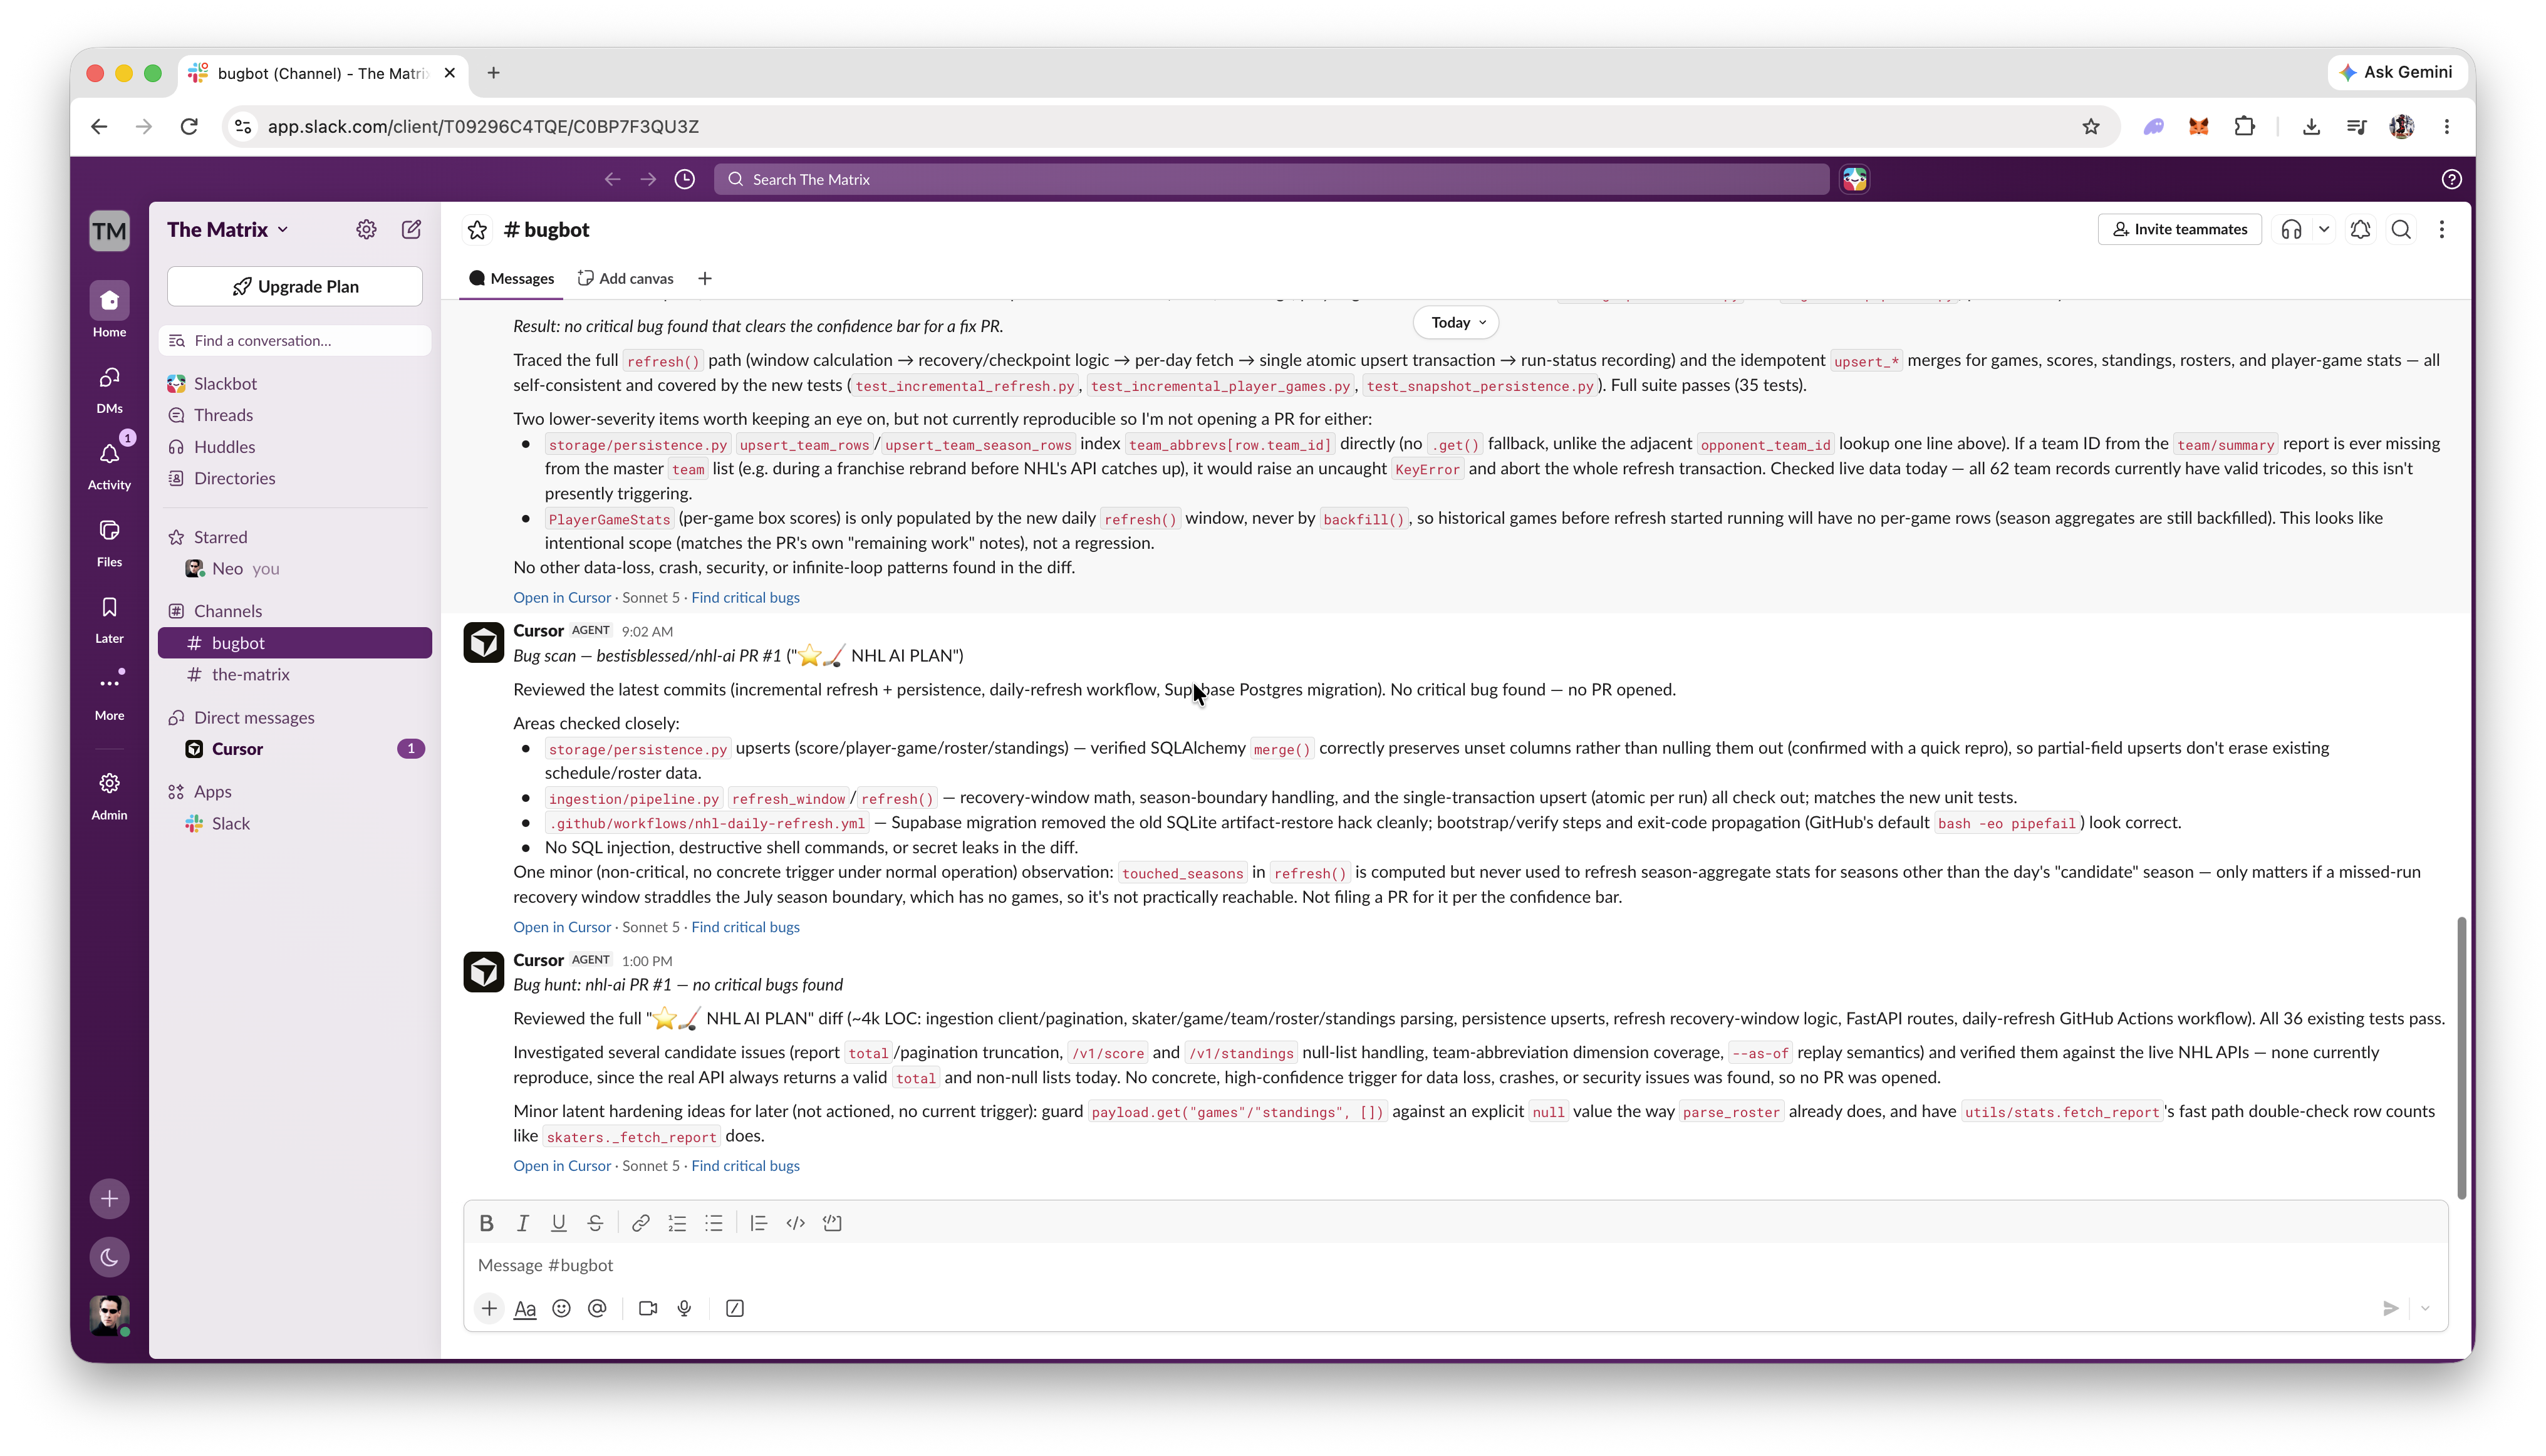

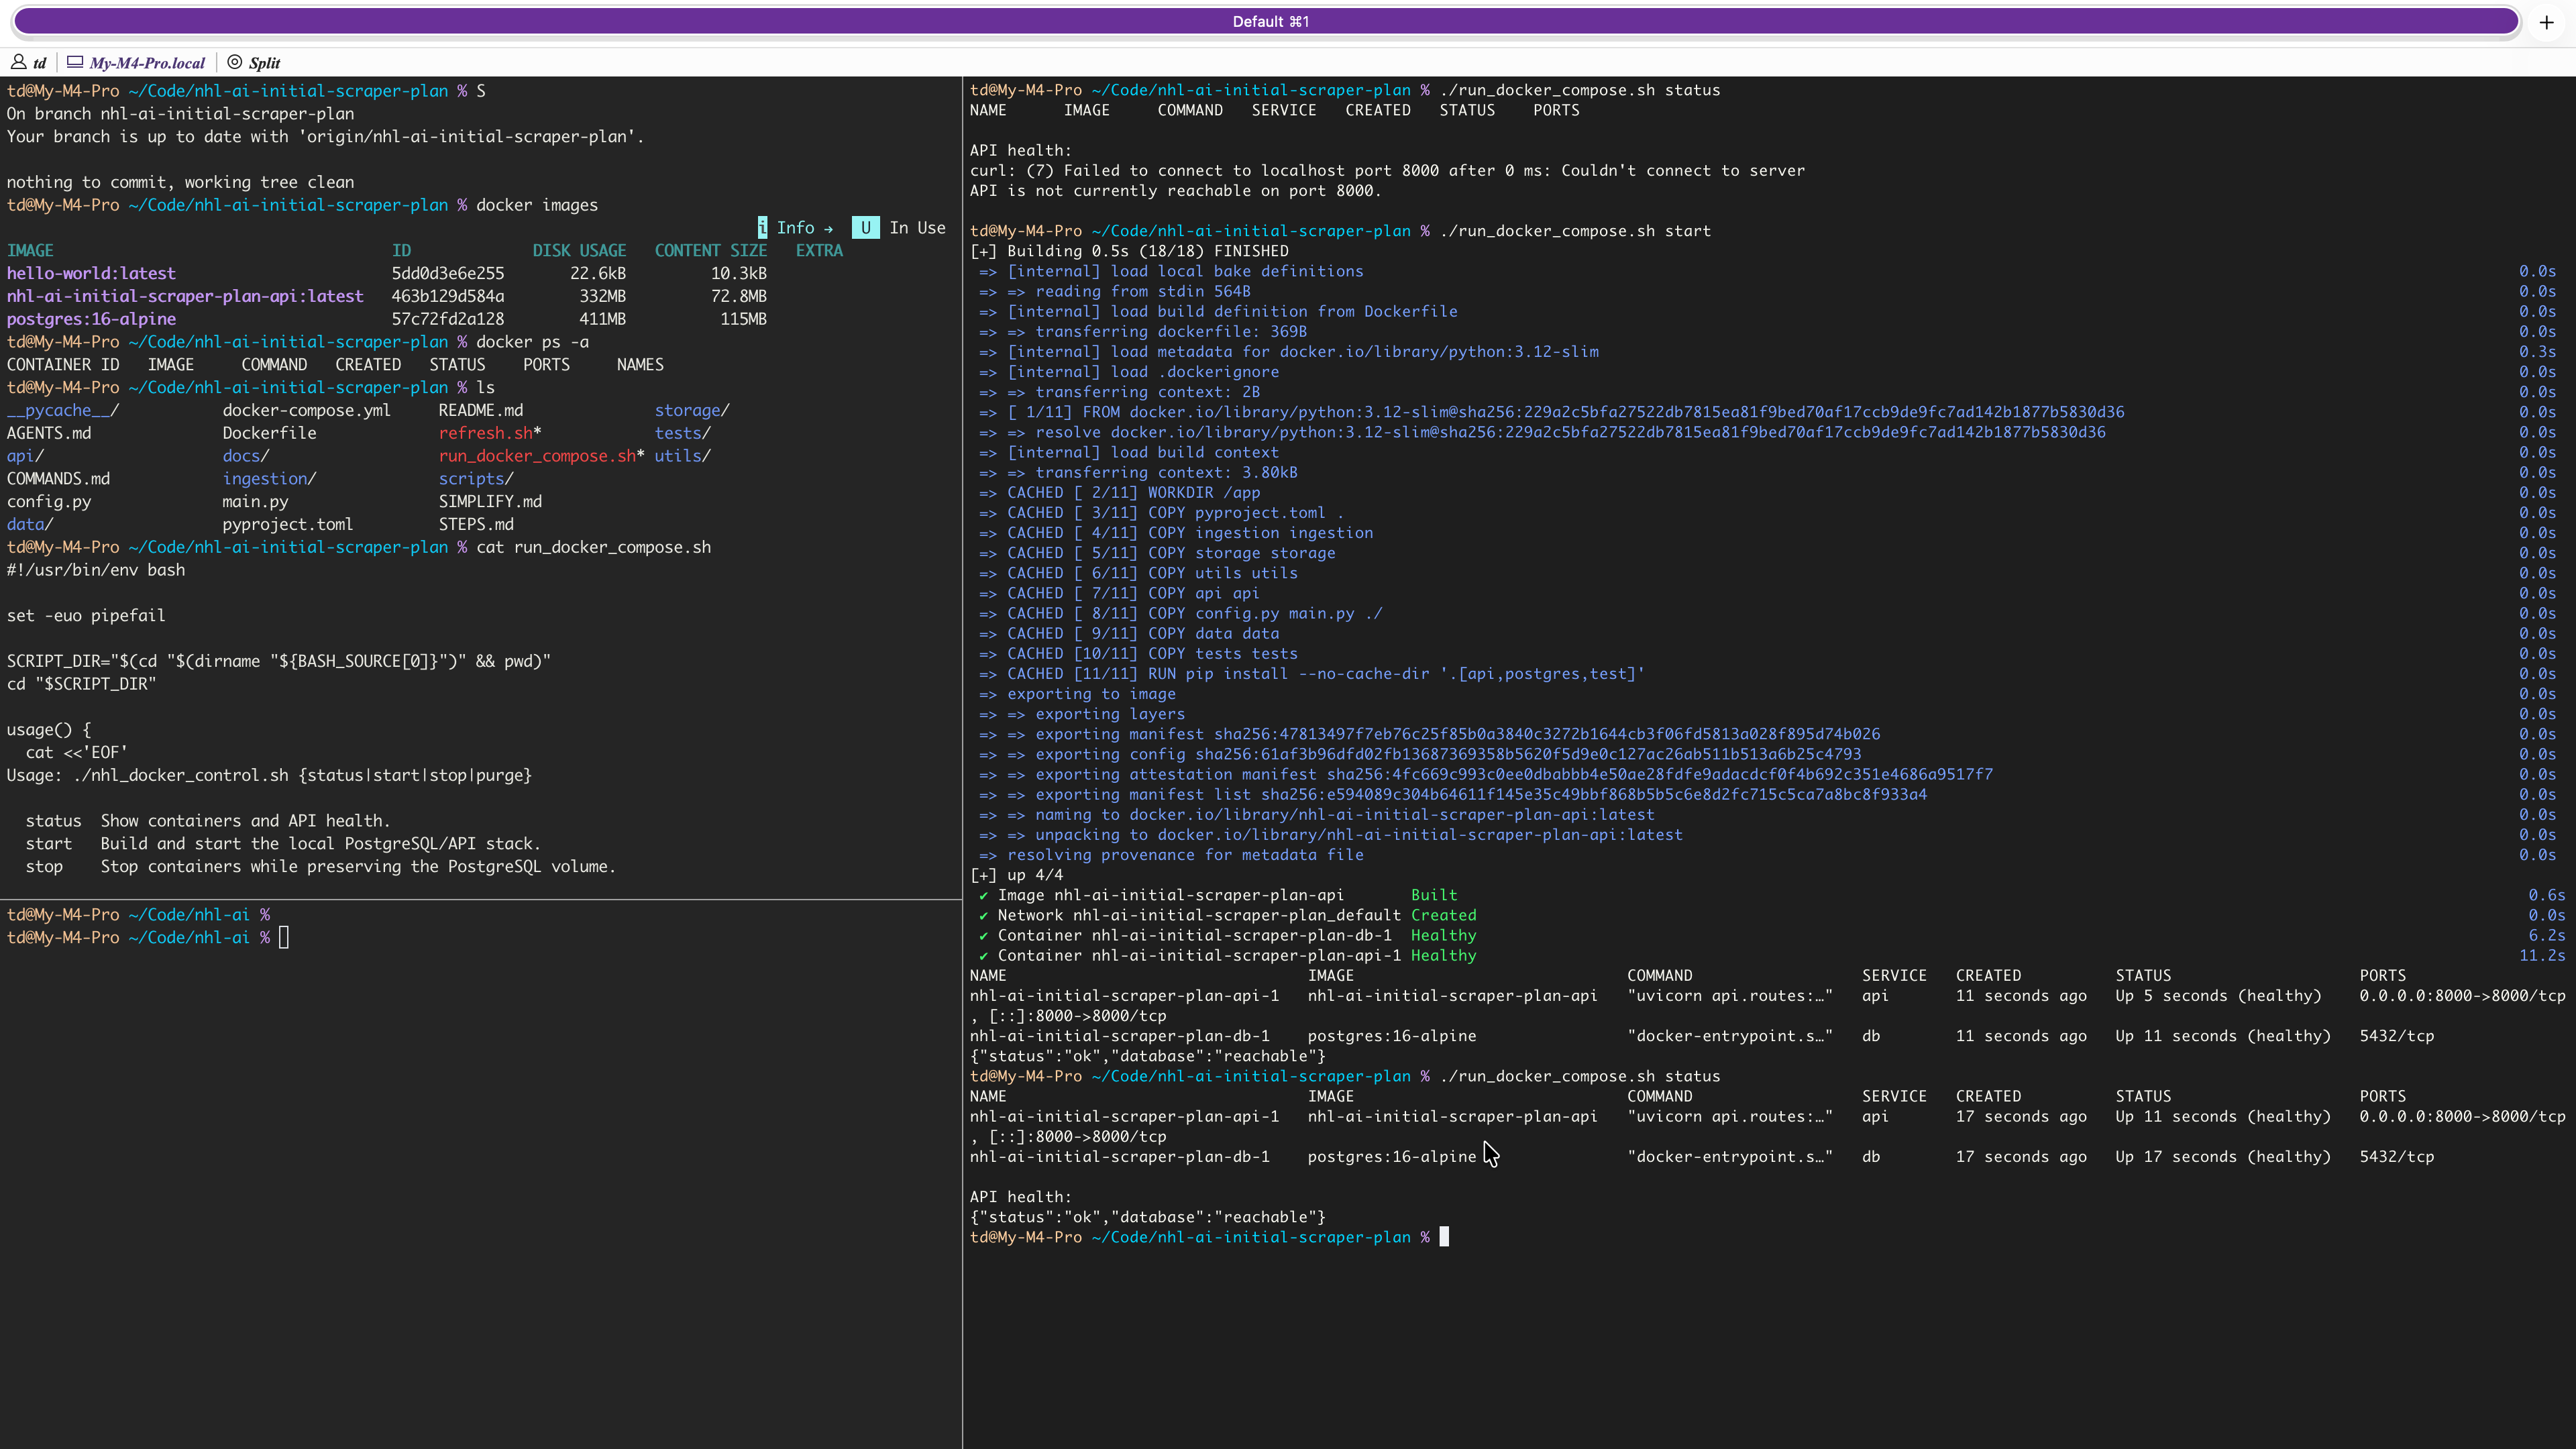

In [26]:
from pathlib import Path
import re
from PIL import Image as PILImage
from IPython.display import display, HTML, Image as NotebookImage

IMAGE_DIR = Path("FINAL-DELIVERABLE-TESTS-AND-EXAMPLES")
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".gif", ".webp", ".bmp"}
MAX_DISPLAY_WIDTH = 1400

def readable_caption(path: Path) -> str:
    name = path.stem.replace("_", " ").replace("-", " ")

    # APIResponse -> API Response
    name = re.sub(r"([A-Z]+)([A-Z][a-z])", r"\1 \2", name)

    # SlackBug -> Slack Bug
    name = re.sub(r"([a-z0-9])([A-Z])", r"\1 \2", name)

    return re.sub(r"\s+", " ", name).strip()


image_paths = sorted(
    path
    for path in IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

if not image_paths:
    print(f"No supported images found in: {IMAGE_DIR.resolve()}")
else:
    display(
        HTML(
            """
            <h2 style="
                text-align: center;
                color: #12304a;
                margin: 10px 0 24px 0;
            ">
                Development Tests, Verifications, and Examples
            </h2>
            """
        )
    )

    for image_path in image_paths:
        caption = readable_caption(image_path)

        with PILImage.open(image_path) as image:
            original_width, original_height = image.size

        # Image displayed first
        display(
            NotebookImage(
                filename=str(image_path),
                width=min(original_width, MAX_DISPLAY_WIDTH),
                retina=True,
            )
        )

        # Small centered caption displayed underneath
        display(
            HTML(
                f"""
                <div style="
                    text-align: center;
                    color: #687985;
                    font-size: 11px;
                    font-style: italic;
                    margin: 6px 0 28px 0;
                    line-height: 1.4;
                ">
                    {caption}
                    <span style="color: #9aa7af;">
                        · {original_width:,} × {original_height:,} px
                    </span>
                </div>
                """
            )
        )